In [1]:
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
from json import loads as load_json
import os
from sklearn import metrics

year = "Run 2"

lumi = {
    "2016APV": "19.52",
    "2016": "16.81",
    "2017": "41.48",
    "2018": "59.83",
    "Run 2": "138"
}

In [2]:
with open( os.path.join( os.getcwd(), "data.json" ), "r" ) as f:
    data = load_json( f.read() )

In [3]:
train_loss = data["LOSS TRAIN"]
validation_loss = data["LOSS VALIDATION"]

## Training Loss

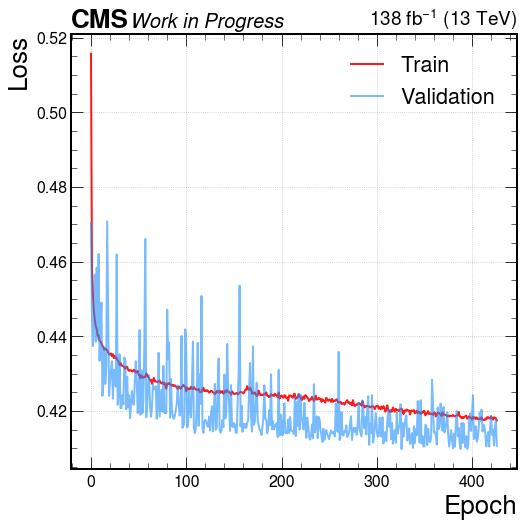

In [59]:
plt.style.use( hep.style.CMS )
plt.figure( figsize = (8,8) )
hep.cms.text( "Work in Progress", fontsize = 20 )
hep.cms.lumitext( lumi[ year ] + " $fb^{-1}$ (13 TeV)", fontsize = 20 )
plt.plot( range( len( train_loss ) ), train_loss, alpha = 0.9, lw = 2, label = "Train", color = "red" )
plt.plot( range( len( validation_loss ) ), validation_loss, alpha = 0.6, lw = 2, label = "Validation", color = "dodgerblue" )

plt.xlabel( "Epoch" )
plt.ylabel( "Loss" )
#plt.yscale( "log" )
plt.tick_params( labelsize = 16 )
plt.legend( loc = "best" )
plt.grid( which = "major" )
plt.show()
plt.close()

## AUC score

In [39]:
tpr, fpr = { "TRAIN": [], "TEST": [] }, { "TRAIN": [], "TEST": [] }

fpr_test_str = data["FPR TEST"] 
for i in range( len( fpr_test_str ) ):
    fpr["TEST"].append( [ float(val) for val in fpr_test_str[i].split(",") ] )
    if len(fpr_test_str[i]) < max( [ len(fpr_test_str[j]) for j in range( len( fpr_test_str ) ) ] ):
        fpr["TEST"][i].append(1.0)

fpr_train_str = data["FPR TRAIN"]
for i in range( len( fpr_train_str ) ):
    fpr["TRAIN"].append( [ float(val) for val in fpr_train_str[i].split(",") ] )
    if len(fpr_train_str[i]) < max( [ len(fpr_train_str[j]) for j in range( len( fpr_train_str ) ) ] ):
        fpr["TRAIN"][i].append(1.0)
        
tpr_test_str = data["TPR TEST"]
for i in range( len( tpr_test_str ) ):
    tpr["TEST"].append( [ float(val) for val in tpr_test_str[i].split(",") ] )
    if len(tpr_test_str[i]) < max( [ len(fpr_test_str[j]) for j in range( len( fpr_test_str ) ) ] ):
        tpr["TEST"][i].append(1.0)
        
tpr_train_str = data["TPR TRAIN"]
for i in range( len( tpr_train_str ) ):
    tpr["TRAIN"].append( [ float(val) for val in tpr_train_str[i].split(",") ] )
    if len(tpr_test_str[i]) < max( [ len(fpr_train_str[j]) for j in range( len( fpr_train_str ) ) ] ):
        tpr["TRAIN"][i].append(1.0)

In [46]:
tpr_avg = { "TRAIN": [], "TEST": [] }
tpr_std = { "TRAIN": [], "TEST": [] }
fpr_avg = { "TRAIN": [], "TEST": [] }
fpr_std = { "TRAIN": [], "TEST": [] }
auc = { "TRAIN": [], "TEST": [] }

for key_ in ["TRAIN","TEST"]:
    for i in range( len( tpr[key_][0] ) ):
        temp_tpr = []
        temp_fpr = []
        for j in range( len( fpr[key_] ) ): 
            temp_tpr.append( tpr[key_][j][i] )
            temp_fpr.append( fpr[key_][j][i] )
        tpr_avg[key_].append( np.mean( temp_tpr ) )
        tpr_std[key_].append( np.std( temp_tpr ) )
        fpr_avg[key_].append( np.mean( temp_fpr ) )
        fpr_std[key_].append( np.std( temp_fpr ) )

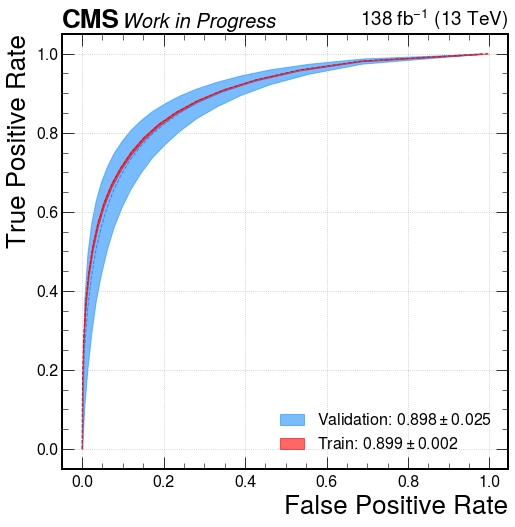

In [60]:
plt.style.use( hep.style.CMS )
plt.figure( figsize = (8,8) )
hep.cms.text( "Work in Progress", fontsize = 20 )
hep.cms.lumitext( lumi[ year ] + " $fb^{-1}$ (13 TeV)", fontsize = 20 )

plt.fill_between(
    fpr_avg["TEST"], y1 = np.array( tpr_avg["TEST"] ) - np.array( tpr_std["TEST"] ), y2 = np.array( tpr_avg["TEST"] ) + np.array( tpr_std["TEST"] ),
    alpha = 0.6, color = "dodgerblue",
    label = "Validation: ${:.3f}\pm{:.3f}$".format( data["AUC TEST K"][0], data["AUC TEST K"][1] ),
)

plt.plot(
    fpr_avg["TEST"], tpr_avg["TEST"],
    ls = "--", lw = 1, color = "dodgerblue"
)

plt.fill_between(
    fpr_avg["TRAIN"], y1 = np.array( tpr_avg["TRAIN"] ) - np.array( tpr_std["TRAIN"] ), y2 = np.array( tpr_avg["TRAIN"] ) + np.array( tpr_std["TRAIN"] ),
    label = "Train: ${:.3f}\pm{:.3f}$".format( data["AUC TRAIN K"][0], data["AUC TRAIN K"][1] ), 
    alpha = 0.6, color = "red"
)

plt.plot(
    fpr_avg["TRAIN"], tpr_avg["TRAIN"],
    ls = "--", lw = 1, color = "red"
)

plt.legend( loc = "lower right", fontsize = 16)

plt.xlabel( "False Positive Rate" )
plt.ylabel( "True Positive Rate" )
plt.tick_params( labelsize = 16 )
plt.grid( which = "major" )
plt.show()
plt.close()